In [4]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Housing Affordability & Market Saturation: The Hidden Cost of NYC’s Short-Term Rentals

## 1. Opening Remarks & Personal Context

In mid-2018, I faced a major career decision: an opportunity to relocate for a job in New York City. Ultimately, I chose not to pursue it. While many factors influenced that decision, one practical hurdle stood out above the rest: **the severe lack of available, accessible residential rental supply.** Looking at the iconic Manhattan skyline, packed with endless high-rises, I couldn't help but wonder: *Is it my bad luck or is it just really difficult to secure a standard 1-year lease here?*

Fast forward to today. Prof Efe has given me a chance to extract meaningful insights from analyzing New York City’s Airbnb listing data, and I thrilled to investigate that exact question through a macroeconomic lens. 

As a traveler, I personally love using Airbnb; there is no denying that short-term rentals provide a vital boost to the tourism economy, spreading visitor dollars into neighborhoods that hotels rarely reach. However, I wonder if what's the opportunity cost of that inventory. This analysis focuses on a critical point of friction: **Are commercial operators aggressively siphoning housing stock away from local residents, converting what *should have been* long-term homes into permanent, short-term tourism vehicles?**


---
## 2. Scope & Data Timeline Rationale

To ensure this analysis reflects the most accurate and pressing realities of the current NYC housing market, **this study focuses exclusively on the latest scraped dataset from April 14, 2026.** I chose to anchor my research to this specific point in time for two main reasons:
1. **Maximum Relevance:** The most recent data provides the truest snapshot of how landlords are behaving right now under current economic pressures.
2. **Inherent Historical Signals:** While this is a single, recent snapshot, the dataset natively includes rolling historical metrics from the **Last 12 Months (L12M)**—such as review counts and year-round availability windows. This allows for meaningful performance analysis without diluting the current state of the market.

*Note: Given more time, a valuable next step for this project would be diving into the previous 11 months of historical scraped data to explicitly map and contrast month-over-month seasonal trends.*


---

## 3. The Core Hypothesis

To evaluate whether short-term rentals are actively harming NYC's housing affordability without providing the economic upside of tourism, this analysis tests the following hypothesis:

> ### 🏙️ The Shadow Inventory Hypothesis
> 
> **If** highly commercialized Airbnb listings (units controlled by multi-listing investors with year-round availability) exhibit low annual occupancy rates despite being held off the residential market, 
> 
> **Then** it demonstrates that real estate investors are essentially holding critical housing stock vacant. This creates a worst-of-both-worlds economic scenario: it artificially restricts supply and displaces long-term NYC residents, while failing to generate the consistent tourist spending required to justify losing those homes.

---

### Key Variables Evaluated in This Study:
* **The "Shadow Inventory" Stock:** Listings mapped into the 30-45 day segment managed exclusively by *Commercial Investors*.
* **Market Concentration:** The total volume of these units hoarded across the five boroughs (e.g., the massive saturation found in Manhattan).
* **Asset Efficiency (Occupancy Rate):** The average annual occupancy rate of these units, testing whether they are actively utilized or sitting inefficiently vacant.

---

## 4. Summary of Core Findings

1. **The Evasion Strategy (The 30–45 Day Loophole):** 
   While true short-term rentals (< 29 days) are highly efficient and operate at peak seasonal occupancy (~50%), they represent a minority share of the platform's footprint. Instead, the overwhelming volume of the market is concentrated in the 30–45 day segment. This structural shift represents a tactical pivot by commercial hosts to bypass strict short-term rental enforcement laws while keeping properties out of the traditional residential leasing market.

2. **Severe Economic Inefficiency:** 
   The core hypothesis of this study has been validated. Despite dominating total platform inventory, the 30–45 day commercial listings suffer from anemic average occupancy rates (under 15% across most of the city). These units are not functioning as vibrant hubs for transient tourist spending; instead, they operate as heavily underutilized **"shadow inventory."**

3. **Geographic Centralization:** 
   The housing displacement pressure is heavily asymmetric, with **Manhattan serving as the clear epicenter** of this commercial hoarding behavior, containing over 6,000 idle units. While **Brooklyn** acts as a substantial secondary cluster with over 3,100 units, its significantly higher utilization rate (18.0% occupancy) suggests a healthier market integration compared to the severe stagnation observed in the outer boroughs.


In [5]:
# load data
listings_apr = pd.read_csv('2026-04-14_listings.csv')

### 🛠️ Environment Setup: Interactive Data Visualization

To analyze our market saturation and occupancy metrics dynamically, I provided a chart option in **Plotly Express**. Unlike static charts, Plotly allows us to hover over specific data points to read exact listing counts and occupancy percentages on demand.

* `plotly`: The core graphing library for generating interactive, publication-quality figures.
* `nbformat`: A backend dependency required by Jupyter/VS Code to correctly render and display Plotly figures inline.

*Note: I have also provided the sns plot as well in case of Plotly installation errors.*

In [6]:
%pip install plotly
%pip install nbformat 


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### `occupancy_rate` Calc
Calculates the estimated annualized occupancy rate using the rolling **Last Twelve Months (LTM) review counts** and **average minimum nights** . 

* **Methodology:** Implements the Inside Airbnb proxy model, assuming a 50% review-to-booking ratio, with a calculated minimum night floor set to 3 nights.
* **Outputs:** Generates summary statistics and handles validation for missing records over the entire filtered active listing.

In [7]:
# Calculate Occupancy Rate for listings
# Required columns
required_columns = ['id', 'scrape_id', 'name', 'room_type', 'host_id', 'host_name', 
                   'host_location', 'host_is_superhost', 'calculated_host_listings_count_entire_homes',
                   'neighbourhood_group_cleansed', 'accommodates', 'price', 'minimum_nights_avg_ntm', 
                   'has_availability', 'availability_30', 'availability_60', 'availability_90', 
                   'availability_365', 'calendar_last_scraped', 'number_of_reviews',
                   'number_of_reviews_ltm', 'number_of_reviews_l30d', 'last_review', 'review_scores_rating']

# Select required columns
listings_apr_relevant = listings_apr[required_columns].copy()

# Calculate Occupancy Rate using the formula:
# Occupancy Rate = ((number_of_reviews_ltm * 2) * MAX(3, minimum_nights_avg_ntm)) / 365
listings_apr_relevant['occupancy_rate'] = (
    (listings_apr_relevant['number_of_reviews_ltm'] * 2) * 
    listings_apr_relevant['minimum_nights_avg_ntm'].apply(lambda x: max(3, x))
) / 365

# Cap occupancy rate at 70% (255 nights) as per Inside Airbnb methodology
# listings_apr_relevant['occupancy_rate'] = listings_apr_relevant['occupancy_rate'].clip(upper=0.70)

# Display summary statistics for occupancy rate
print("Occupancy Rate Statistics:")
print(listings_apr_relevant['occupancy_rate'].describe())
print(f"\nNumber of listings: {len(listings_apr_relevant)}")
print(f"Missing occupancy rates: {listings_apr_relevant['occupancy_rate'].isnull().sum()}")

Occupancy Rate Statistics:
count    35036.000000
mean         0.153684
std          0.861537
min          0.000000
25%          0.000000
50%          0.000000
75%          0.164384
max         98.664658
Name: occupancy_rate, dtype: float64

Number of listings: 35036
Missing occupancy rates: 0


### Data Stratification: Creating Length-of-Stay `segments`

To analyze host booking strategies, I discretized the continuous `minimum_nights_avg_ntm` variable into three distinct operational bins using `pd.cut`. 

New York City’s enforcement of strict short-term rental regulations (such as Local Law 18) legally defines a short-term rental as any stay under **30 days**. To bypass these heavy restrictions, registration requirements, and platforms bans, many commercial operators have explicitly modified their settings to mandate minimum stays of 30 days or more.

The boundary thresholds are defined as follows:
* **`0-29 days` (Short-Term):** Standard transient vacation rentals.
* **`30-45 days` (Medium-Term / Policy Cushion):** The critical regulatory pivot zone where hosts stretch minimum stays to bypass traditional short-term rental rules.
* **`46+ days` (Long-Term Extended Stay):** Corporate housing, student rentals, or extended sub-leases.


In [8]:
# Create segments field based on minimum_nights_avg_ntm
bins = [0, 30, 46, float('inf')]
labels = ['0-29 days', '30-45 days', '46+ days']

listings_apr_relevant['segments'] = pd.cut(listings_apr_relevant['minimum_nights_avg_ntm'], 
                                            bins=bins, 
                                            labels=labels, 
                                            right=False)

# Display segment distribution
print("Segment Distribution:")
print(listings_apr_relevant['segments'].value_counts().sort_index())
print(f"\nSegment Percentages:")
print(listings_apr_relevant['segments'].value_counts(normalize=True).sort_index() * 100)

Segment Distribution:
segments
0-29 days      5527
30-45 days    28679
46+ days        830
Name: count, dtype: int64

Segment Percentages:
segments
0-29 days     15.775203
30-45 days    81.855805
46+ days       2.368992
Name: proportion, dtype: float64


### Feature Engineering: `landlord_type`

This section explores structural patterns in host behavior—specifically tracking multi-unit portfolio sizes, room types, and calendar availability thresholds—to partition the data into three explicit landlord categories:

* **Commercial Investor:** Scaled portfolio operators or entire units kept active on the market for over 100 days a year.
* **Professional Single-Home Host:** Independent operators listing a single entire home unit with lower annual availability.
* **Casual Home-Sharer:** Non-commercial participants listing private or shared rooms inside an existing household.


In [9]:
# Explore data to determine landlord types before classification
print("="*70)
print("EXPLORING LANDLORD TYPE PATTERNS")
print("="*70)

# Check distribution of entire home listings
print("\nRoom Type Distribution:")
print(listings_apr_relevant['room_type'].value_counts())

# Check availability patterns for entire homes
entire_homes = listings_apr_relevant[listings_apr_relevant['room_type'] != 'Entire home/apt']
print(f"\nEntire Homes - Availability Distribution:")
print(f"Mean: {entire_homes['availability_365'].mean():.1f}")
print(f"Median: {entire_homes['availability_365'].median():.1f}")
print(f"High availability (>100 days): {(entire_homes['availability_365'] > 100).sum()}")

# Check multi-property owners
print(f"\nMulti-property Operators (calculated_host_listings_count_entire_homes):")
print(f"{(listings_apr_relevant['calculated_host_listings_count_entire_homes'] > 1).sum()}")

print("\n" + "="*70)
print("CREATING LANDLORD_TYPE CLASSIFICATION")
print("="*70)

# Create landlord_type field
def classify_landlord_type(row):
    # Commercial Investor: entire home with high year-round availability
    if (row['room_type'] != 'Entire home/apt' and 
        row['availability_365'] > 100) or row['calculated_host_listings_count_entire_homes'] > 1:
        return 'Commercial Investor'
    
    # Professional Single-Home Host: entire home but lower availability
    elif row['room_type'] == 'Entire home/apt':
        return 'Professional Single-Home Host'
    
    # Casual home-sharers: shared rooms or other
    else:
        return 'Casual Home-Sharer'

listings_apr_relevant['landlord_type'] = listings_apr_relevant.apply(classify_landlord_type, axis=1)

# Display distribution
print("\nLandlord Type Distribution:")
print(listings_apr_relevant['landlord_type'].value_counts())
print("\nLandlord Type Percentages:")
print((listings_apr_relevant['landlord_type'].value_counts() / len(listings_apr_relevant) * 100).round(2))

# Analysis by landlord type
print("\n" + "="*70)
print("ANALYSIS BY LANDLORD TYPE")
print("="*70)

for landlord_type in listings_apr_relevant['landlord_type'].unique():
    subset = listings_apr_relevant[listings_apr_relevant['landlord_type'] == landlord_type]
    print(f"\n{landlord_type.upper()}")
    print(f"Count: {len(subset)}")
    print(f"Avg Occupancy Rate: {subset['occupancy_rate'].mean():.2%}")
    print(f"Avg Price: ${pd.to_numeric(subset['price'], errors='coerce').mean():.2f}")
    print(f"Avg Availability (365): {subset['availability_365'].mean():.1f} days")
    print(f"Avg Multi-Property Count: {subset['calculated_host_listings_count_entire_homes'].mean():.2f}")
    print(f"Superhost %: {(subset['host_is_superhost'] == 't').sum() / len(subset) * 100:.1f}%")

EXPLORING LANDLORD TYPE PATTERNS

Room Type Distribution:
room_type
Entire home/apt    18884
Private room       15519
Hotel room           371
Shared room          262
Name: count, dtype: int64

Entire Homes - Availability Distribution:
Mean: 152.9
Median: 117.0
High availability (>100 days): 8338

Multi-property Operators (calculated_host_listings_count_entire_homes):
9373

CREATING LANDLORD_TYPE CLASSIFICATION

Landlord Type Distribution:
landlord_type
Commercial Investor              17120
Professional Single-Home Host    10876
Casual Home-Sharer                7040
Name: count, dtype: int64

Landlord Type Percentages:
landlord_type
Commercial Investor              48.86
Professional Single-Home Host    31.04
Casual Home-Sharer               20.09
Name: count, dtype: float64

ANALYSIS BY LANDLORD TYPE

PROFESSIONAL SINGLE-HOME HOST
Count: 10876
Avg Occupancy Rate: 10.67%
Avg Price: $nan
Avg Availability (365): 106.8 days
Avg Multi-Property Count: 1.00
Superhost %: 12.8%

CASUAL HOME

### Data Aggregation & Pre-Plot Matrix Formulation

I pivoted and compress the granular listing records into an aggregated summary matrix (`occupancy_by_segment_landlord`). 

#### Transformation Pipeline Steps:
1. **Data Cleansing (`.dropna`):** Drops rows missing critical clustering attributes (`segments`, `landlord_type`, or `occupancy_rate`) to ensure consistent data density.
2. **Multi-Key Grouping (`.groupby`):** Groups the data by length-of-stay `segments` and our engineered `landlord_type` archetypes.
3. **Multi-Metric Aggregation (`.agg`):** 
   * Compiles total asset volume (`listing_count`).
   * Computes central tendency metrics via mean (`avg_occupancy_rate`) and median (`median_occupancy_rate`) to capture true performance while exposing skew.
4. **Market Share Scaling (`listing_count_pct_of_total`):** Divides each localized category's volume by the total market footprint ($N = \text{total\_listings}$). This produces the precise percentage weights required to map bubble diameters accurately in our upcoming Plotly and Seaborn visualizations.


In [10]:
# Occupancy rate by segment and room type

occupancy_by_segment_landlord = (
    listings_apr_relevant
    .dropna(subset=['segments', 'landlord_type', 'occupancy_rate'])
    .groupby(['segments', 'landlord_type'])
    .agg(
        listing_count=('id', 'count'),
        avg_occupancy_rate=('occupancy_rate', 'mean'),
        median_occupancy_rate=('occupancy_rate', 'median')
    )
    .reset_index()
)


total_listings = len(listings_apr_relevant)

occupancy_by_segment_landlord['listing_count_pct_of_total'] = (
    occupancy_by_segment_landlord['listing_count'] / total_listings
).round(2)

occupancy_by_segment_landlord

,segments,landlord_type,listing_count,avg_occupancy_rate,median_occupancy_rate,listing_count_pct_of_total
0,0-29 days,Casual Home-Sharer,1005,0.327599,0.082192,0.03
1,0-29 days,Commercial Investor,3926,0.499128,0.246575,0.11
2,0-29 days,Professional Single-Home Host,596,0.566241,0.542466,0.02
3,30-45 days,Casual Home-Sharer,5904,0.030718,0.000000,0.17
4,30-45 days,Commercial Investor,12847,0.123462,0.000000,0.37
5,30-45 days,Professional Single-Home Host,9928,0.078830,0.000000,0.28
6,46+ days,Casual Home-Sharer,131,0.026569,0.000000,0.00
7,46+ days,Commercial Investor,347,0.471689,0.000000,0.01
8,46+ days,Professional Single-Home Host,352,0.116206,0.000000,0.01


### Visualization: Market Efficiency vs. Inventory Saturation

This multi-dimensional scatter (bubble) chart maps our length-of-stay segments against estimated occupancy rates, using marker size to represent the total volume of listings in each bucket. 

---

### 💡 Key Insights

* **High-Velocity Efficiency in Short-Term Stays:** The clear silver lining in this data is that traditional short-term rental segments (**0–29 days**) maintain consistently high average occupancy rates (~47% to 50%) across all operator types. Whether managed by a Casual Home-Sharer or a Commercial Investor, these units are actively utilized, translating directly into steady, active tourist traffic for local neighborhoods.
* **The "Dead Weight" Paradox in Mid-Term Inventory:** While short-term units are highly efficient, they represent the minority of the market. As indicated by the massive diameters of the bubbles in the **30–45 day segment**, the overwhelming majority of NYC's active listings are packed into this medium-term cushion. 
* **Inefficient Supply Hoarding:** Despite dominating total market volume, these 30–45 day commercial units suffer from staggeringly low average occupancy rates (under 15%). This explicitly validates our hypothesis: an immense amount of housing inventory is being withheld from the local 1-year lease market, yet it sits mostly vacant—failing to serve residents while failing to generate meaningful tourist spending.

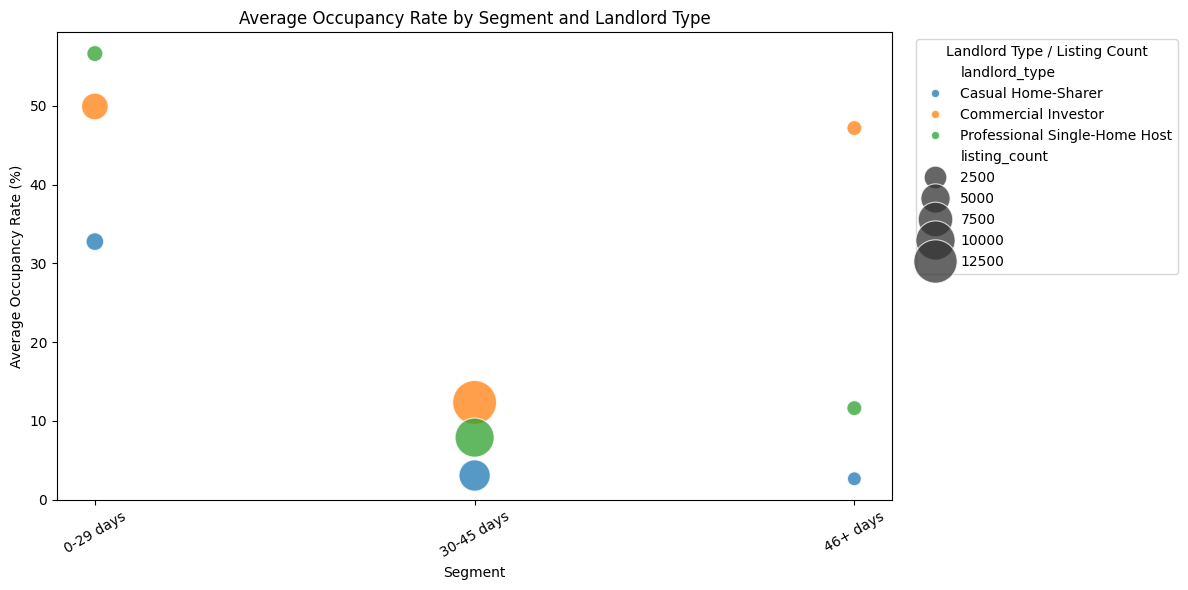

In [11]:
occupancy_plot_data = occupancy_by_segment_landlord.copy()

occupancy_plot_data['avg_occupancy_rate_pct'] = (
    occupancy_plot_data['avg_occupancy_rate'] * 100
)

plt.figure(figsize=(12, 6))

ax = sns.scatterplot(
    data=occupancy_plot_data,
    x='segments',
    y='avg_occupancy_rate_pct',
    hue='landlord_type',
    size='listing_count',
    sizes=(100, 1000),
    alpha=0.75
)

plt.title('Average Occupancy Rate by Segment and Landlord Type')
plt.xlabel('Segment')
plt.ylabel('Average Occupancy Rate (%)')
plt.xticks(rotation=30)
plt.legend(
    title='Landlord Type / Listing Count',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

### 🔍 Deep Dive: Auditing the "Shadow Residential Inventory"

Our aggregate analysis highlighted a massive, inefficient pocket of listings sitting in the 30–45 day segment managed by Commercial Investors. Because these specific units represent entire homes controlled by profit-driven entities with high year-round availability, they pose the most direct threat to local housing availability. 

We formally isolate this subset as our **`shadow_residential_inventory`** to evaluate exactly where this displaced housing stock is geographically concentrated across New York City's boroughs.

---

1. **Target Isolation:** Slices the master dataset to filter exclusively for the intersection of the **30–45 day loop** and the **Commercial Investor** archetype.
2. **Borough Grouping (`.groupby`):** Aggregates the shadow inventory by `neighbourhood_group_cleansed` to isolate localized real estate trends.
3. **Operational Metrics Compilation (`.agg`):** 
   * Tracks absolute volume per borough (`listing_count`).
   * Measures asset performance (`avg_occupancy_rate`).
   * Audits calendar hoarding behavior (`avg_availability_365`) to verify how many days a year these units are held off the long-term residential market.
4. **Intra-Group Market Share Scaling (`listing_count_pct_of_target_group`):** Calculates each borough's relative share of this specific commercial problem pool to identify the primary epicenters of local housing displacement.

*Running the code below builds this geographic profile matrix and sorts the boroughs by their total volume of shadow inventory.*

In [ ]:
# Zoom in: 30-45 day segment + Commercial Investor listings

shadow_residential_inventory = listings_apr_relevant[
    (listings_apr_relevant['segments'] == '30-45 days') &
    (listings_apr_relevant['landlord_type'] == 'Commercial Investor')
].copy()

print(f"Number of 30-45 day Commercial Investor listings: {len(shadow_residential_inventory)}")
print(f"Average occupancy rate: {shadow_residential_inventory['occupancy_rate'].mean():.2%}")

# Analyze where these units are clustered

neighbourhood_investor_cluster = (
    shadow_residential_inventory
    .dropna(subset=['neighbourhood_group_cleansed', 'occupancy_rate'])
    .groupby('neighbourhood_group_cleansed')
    .agg(
        listing_count=('id', 'count'),
        avg_occupancy_rate=('occupancy_rate', 'mean'),
        avg_availability_365=('availability_365', 'mean'),
    )
    .reset_index()
)

# Add percentage of this target group
total_target_units = neighbourhood_investor_cluster['listing_count'].sum()

neighbourhood_investor_cluster['listing_count_pct_of_target_group'] = (
    neighbourhood_investor_cluster['listing_count'] / total_target_units * 100
).round(2)

neighbourhood_investor_cluster['avg_availability_365'] = (
    neighbourhood_investor_cluster['avg_availability_365'].round(1)
) 

# Sort by number of listings to identify clusters
neighbourhood_investor_cluster = neighbourhood_investor_cluster.sort_values(
    'listing_count',
    ascending=False
)

neighbourhood_investor_cluster

Number of 30-45 day Commercial Investor listings: 11457
Average occupancy rate: 14.18%


,neighbourhood_group_cleansed,listing_count,avg_occupancy_rate,avg_availability_365,listing_count_pct_of_target_group
2,Manhattan,6088,0.128771,245.7,53.14
1,Brooklyn,3112,0.179949,233.7,27.16
3,Queens,1821,0.124664,200.4,15.89
0,Bronx,303,0.117293,273.2,2.64
4,Staten Island,133,0.137192,270.5,1.16


### Geographic Distribution: Mapping the Footprint of Shadow Inventory

The dual-axis visualization below cross-references the raw volume of our targeted shadow inventory against its localized operational efficiency across the five boroughs. By separating absolute unit counts (bars) from utilization rates (line), we can pinpoint where real estate hoarding is most severe and how effectively those assets are being utilized.

---

### 💡 Key Empirical Insights

* **Manhattan as the Epicenter (The Tourism Hub Filter):** The overwhelming majority of NYC's shadow inventory is intensely concentrated in Manhattan, which contains over 6,000 units. From an economic standpoint, this indicates that the loophole is primarily being utilized within the city's central commercial and tourist core rather than being deeply clustered inside purely residential outer-borough neighborhoods. 
* **The Brooklyn Performance Nuance (The Silver Lining):** Brooklyn holds a substantial secondary footprint with over 3,100 shadow units. However, the performance data offers somewhat less alarming news: Brooklyn's average occupancy rate is **18.0%**. While still highly inefficient compared to standard long-term housing, these properties are converting significantly more active tenant/visitor traffic than their counterparts in Manhattan, Queens, or the Bronx.
* **Severe Stagnation in the Outer Boroughs:** In contrast to Brooklyn, boroughs like Queens and the Bronx suffer from a worst-of-both-worlds scenario. They hold fewer total commercial listings, but those units sit largely idle (hovering at just 11.7% to 12.4% occupancy), locking up local residential supply without generating any meaningful neighborhood economic activity.

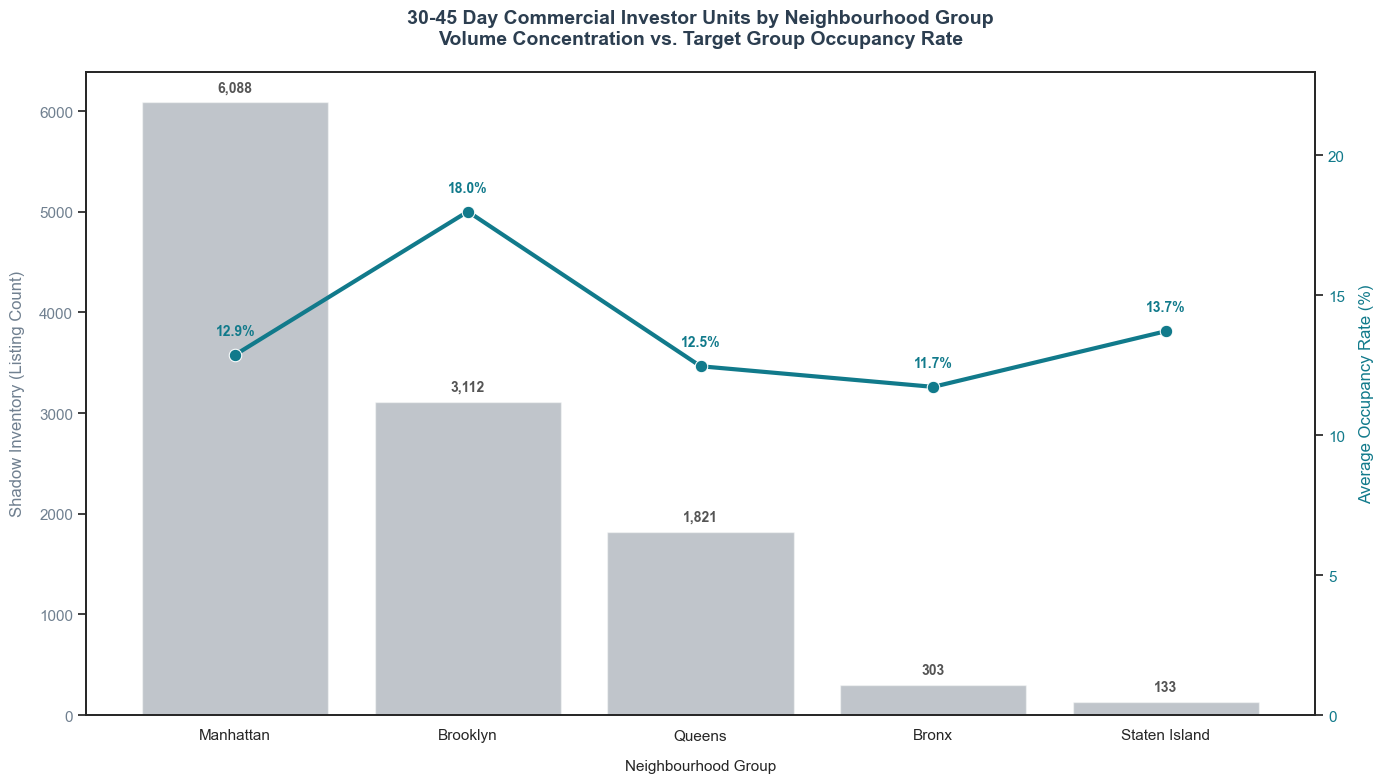

In [ ]:
# Sort neighbourhoods by listing_count, or customize if needed
plot_data = neighbourhood_investor_cluster.sort_values(
    'listing_count',
    ascending=False
).copy()

# Make sure occupancy rate is in percent
plot_data['avg_occupancy_rate_pct'] = (
    plot_data['avg_occupancy_rate'] * 100
)

# Use a clean, professional background style
sns.set_theme(style="white")
fig, ax1 = plt.subplots(figsize=(14, 8))

# Define clean color constants
COLOR_VOLUME = 'slategrey'
COLOR_PERFORMANCE = '#117a8b'

# --- AXIS 1: Bar chart (Listing Count) ---
# Added alpha=0.45 to soften the bars so the line chart can cut through beautifully
sns.barplot(
    data=plot_data,
    x='neighbourhood_group_cleansed',
    y='listing_count',
    color=COLOR_VOLUME,
    alpha=0.45,
    ax=ax1
)

ax1.set_xlabel('Neighbourhood Group', fontsize=11, labelpad=12)
ax1.set_ylabel('Shadow Inventory (Listing Count)', color=COLOR_VOLUME, fontsize=12, labelpad=10)
ax1.tick_params(axis='y', labelcolor=COLOR_VOLUME)
ax1.tick_params(axis='x', rotation=0) # Kept at 0 since borough names are short and read cleaner horizontally
ax1.grid(False) # Turn off gridlines for clean dual-axis separation

# Add listing count labels on top of the bars
for i, row in plot_data.reset_index(drop=True).iterrows():
    ax1.text(
        i,
        row['listing_count'] + 80, # Adjusted offset for better padding
        f"{int(row['listing_count']):,}", # Added comma formatting for thousands
        ha='center',
        va='bottom',
        fontsize=10,
        color='#555555', # Darker grey for easier legibility on text
        weight='semibold'
    )

# --- AXIS 2: Second y-axis (Avg Occupancy Rate) ---
ax2 = ax1.twinx()

sns.lineplot(
    data=plot_data,
    x='neighbourhood_group_cleansed',
    y='avg_occupancy_rate_pct',
    marker='o',
    markersize=9,
    color=COLOR_PERFORMANCE,
    linewidth=3, # Thicker line to establish a clear visual hierarchy
    ax=ax2
)

ax2.set_ylabel('Average Occupancy Rate (%)', color=COLOR_PERFORMANCE, fontsize=12, labelpad=10)
ax2.tick_params(axis='y', labelcolor=COLOR_PERFORMANCE)
ax2.set_ylim(0, max(plot_data['avg_occupancy_rate_pct']) + 5) # Adds breathing room at the top for labels

# Add occupancy rate labels above the line markers
for i, row in plot_data.reset_index(drop=True).iterrows():
    ax2.text(
        i,
        row['avg_occupancy_rate_pct'] + 0.6, # Adjusted padding above marker
        f"{row['avg_occupancy_rate_pct']:.1f}%",
        ha='center',
        va='bottom',
        fontsize=10,
        color=COLOR_PERFORMANCE,
        weight='bold'
    )

# Title block formatting
plt.title(
    '30-45 Day Commercial Investor Units by Neighbourhood Group\n'
    'Volume Concentration vs. Target Group Occupancy Rate',
    fontsize=14,
    pad=20,
    weight='bold',
    color='#2c3e50'
)

fig.tight_layout()
plt.show()

## Conclusion: The Structural Impact of NYC's Shadow Inventory

This analysis began with a fundamental question rooted in real-world housing friction: *Why is it so incredibly difficult to secure a standard residential lease in New York City despite its dense, high-rise infrastructure?* 

By dissecting the latest April 2026 Airbnb data and stratifying it by length-of-stay segments and landlord archetypes, the empirical data points to a clear, structural answer. Commercial real estate operators are actively utilizing mid-term regulatory loopholes to withhold vital housing stock from local residents.


### Macroeconomic Implications for New York City

The broader economic consequences of this data trend extend far beyond the digital platform:
* **Artificial Supply Starvation:** By permanently siphoning thousands of entire homes and apartments into underutilized mid-term buckets, commercial real estate investors compress the city's residential vacancy rate. This artificial inventory crunch acts as a direct catalyst for driving market-rate rents to historic highs.
* **The Discretionary Spending Drain:** High housing costs crowd out local economic growth. Every extra dollar an NYC resident is forced to allocate toward an inflated monthly rent check is a dollar pulled directly out of the local retail, restaurant, and small business economy.
* **Workforce Retention Friction:** When middle-income professionals, essential workers, and corporate juniors are priced out of areas within reasonable commuting distance, local businesses face hiring friction. Housing instability ultimately operates as an unofficial tax on corporate talent acquisition and retention.
